FICHIER TEMPORAIRE

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

np.random.seed(42)


[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985
 0.83244264 0.21233911 0.18182497 0.18340451 0.30424224 0.52475643
 0.43194502 0.29122914 0.61185289 0.13949386 0.29214465 0.36636184
 0.45606998 0.78517596 0.19967378 0.51423444 0.59241457 0.04645041
 0.60754485 0.17052412 0.06505159 0.94888554 0.96563203 0.80839735
 0.30461377 0.09767211 0.68423303 0.44015249 0.12203823 0.49517691
 0.03438852 0.9093204  0.25877998 0.66252228 0.31171108 0.52006802
 0.54671028 0.18485446] [0.96958463 0.77513282 0.93949894 0.89482735 0.59789998 0.92187424
 0.0884925  0.19598286 0.04522729 0.32533033 0.38867729 0.27134903
 0.82873751 0.35675333 0.28093451 0.54269608 0.14092422 0.80219698
 0.07455064 0.98688694 0.77224477 0.19871568 0.00552212 0.81546143
 0.70685734 0.72900717 0.77127035 0.07404465 0.35846573 0.11586906
 0.86310343 0.62329813 0.33089802 0.06355835 0.31098232 0.32518332
 0.72960618 0.63755747 0.88721274 0.47

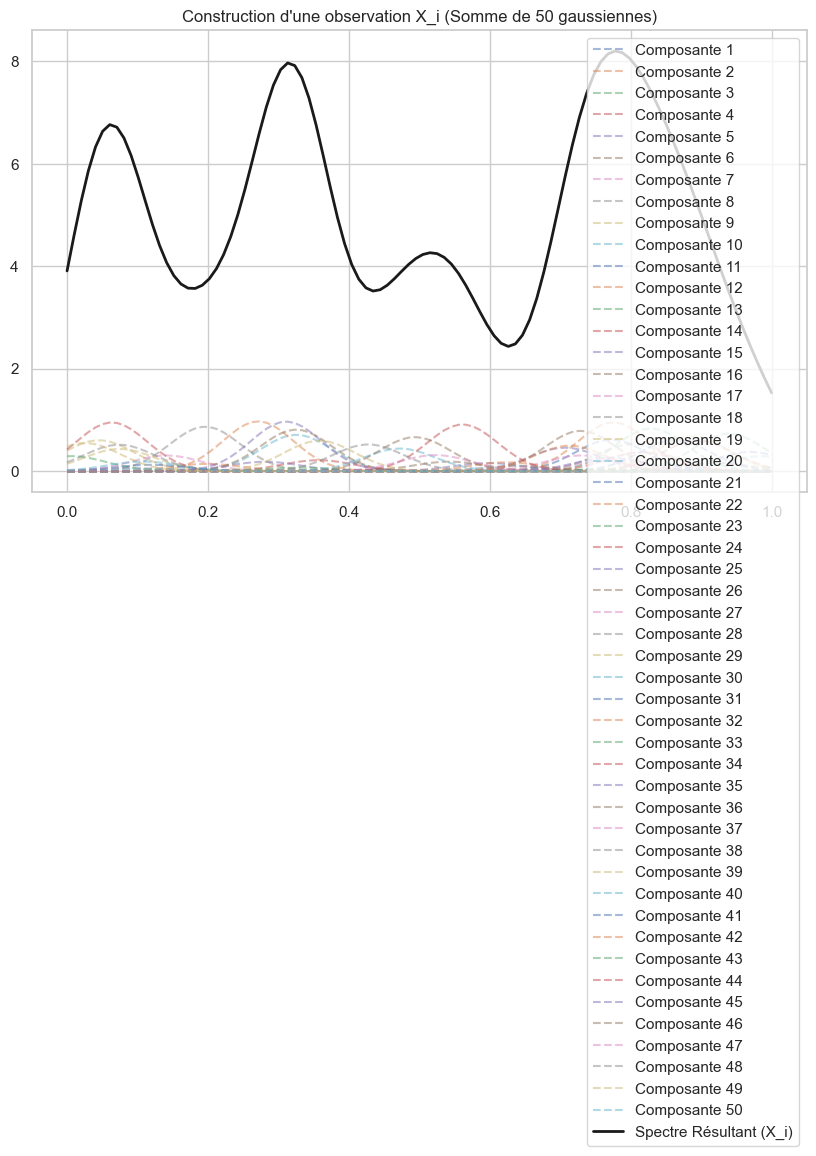

In [34]:
# Paramètres pour une seule observation
p = 100         # Nombre de variables (longueurs d'onde)
nondes = 50     # Nombre de pics (gaussiennes) qui composent le signal
sigma = 0.05    # Largeur des pics

# 1. L'axe des x (les longueurs d'onde)
x_axis = np.linspace(0, 1, p)

# 2. Génération aléatoire des pics
# En R: ampl=matrix(runif(nondes*n)...) -> Loi Uniforme [0, 1]
# En R: modes=runif(nondes) -> Position des pics sur l'axe x
amplitudes = np.random.uniform(0, 1, nondes)
modes = np.random.uniform(0, 1, nondes)

print(amplitudes, modes)

# 3. Construction du signal
# On crée un vecteur vide et on ajoute les gaussiennes une par une
signal = np.zeros(p)

plt.figure()
# On trace quelques gaussiennes individuelles en pointillé pour comprendre
for i in range(nondes):  # Juste les 5 premières pour ne pas surcharger
    gauss = amplitudes[i] * np.exp(-(x_axis - modes[i])**2 / (2 * sigma**2))
    plt.plot(x_axis, gauss, '--', alpha=0.5, label=f'Composante {i+1}')
    signal += gauss

# On ajoute le reste des 45 gaussiennes au signal
for i in range(5, nondes):
    gauss = amplitudes[i] * np.exp(-(x_axis - modes[i])**2 / (2 * sigma**2))
    signal += gauss

plt.plot(x_axis, signal, 'k-', linewidth=2, label='Spectre Résultant (X_i)')
plt.title(f"Construction d'une observation X_i (Somme de {nondes} gaussiennes)")
plt.legend()
plt.show()


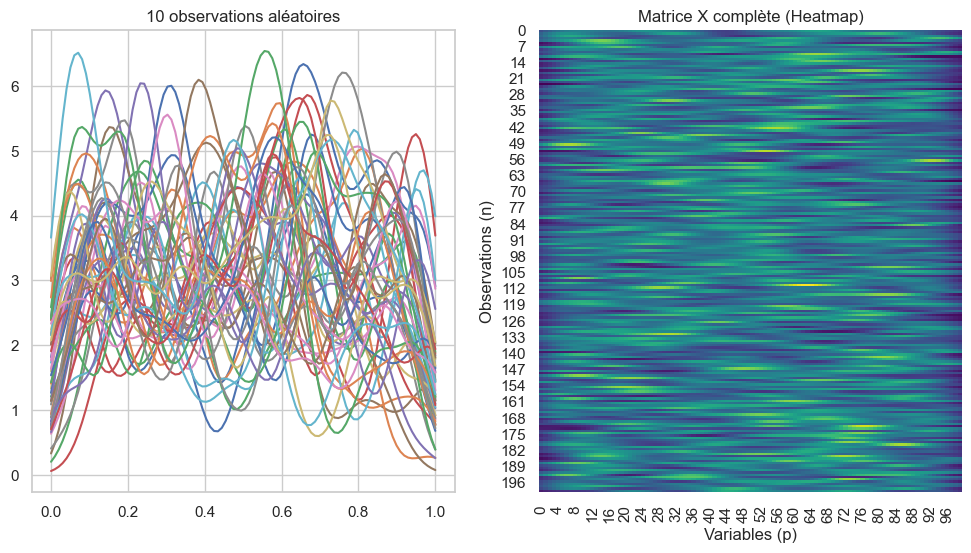

In [35]:
n = 200
p = 100 
nondes = 50
sigma = 0.05

# Initialisation de X
X = np.zeros((n, p))
x_axis = np.linspace(0, 1, p)

# Boucle sur les observations (comme dans le code R original)
# On pourrait vectoriser plus agressivement, mais restons lisibles
for j in range(n):
    amplitudes = np.random.uniform(0, 1, nondes)
    modes = np.random.uniform(0, 1, nondes)
    
    # Astuce Numpy : Broadcasting pour éviter la boucle sur 'nondes'
    # (p, 1) - (1, nondes) -> Matrice (p, nondes)
    delta = x_axis[:, np.newaxis] - modes[np.newaxis, :]
    gaussians = amplitudes * np.exp(-(delta**2) / (2 * sigma**2))
    
    # Somme sur l'axe des ondes pour obtenir le signal final
    X[j, :] = np.sum(gaussians, axis=1)

# Visualisation de l'ensemble des données
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
# Afficher 10 spectres au hasard
for i in range(nondes):
    plt.plot(x_axis, X[i, :])
plt.title("10 observations aléatoires")

plt.subplot(1, 2, 2)
sns.heatmap(X, cmap="viridis", cbar=False)
plt.title("Matrice X complète (Heatmap)")
plt.xlabel("Variables (p)")
plt.ylabel("Observations (n)")
plt.show()


Bornes des intervalles (indices) : [  0  10  32  55  78 100]


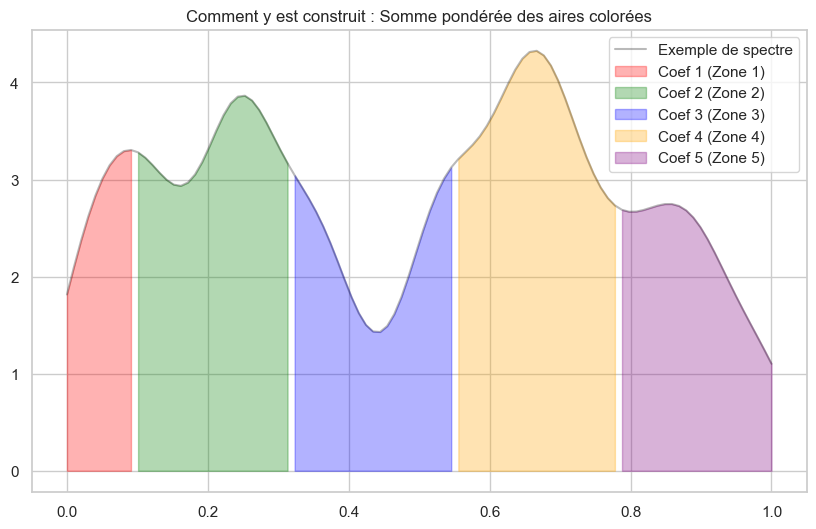

In [36]:
# Coefficients du papier : "true regression coefficients"
int_coef = np.array([1, 2, 3, 4, 5])

# Découpage des indices comme dans le R
# R: seq(10, 100, length.out=length(int.coef)) * sum(p) / 100
# Cela crée des bornes en pourcentage : 10%, 32.5%, 55%, 77.5%, 100%
limits_pct = np.linspace(10, 100, len(int_coef))
pif = np.round(limits_pct * p / 100).astype(int)
# On ajoute le début (indice 0 en Python, 1 en R)
pif = np.concatenate(([0], pif))

print(f"Bornes des intervalles (indices) : {pif}")

# Calcul de y0 (sans bruit)
y0 = np.zeros(n)
sumX = np.zeros((n, len(int_coef)))

# Pour chaque intervalle, on somme les valeurs de X (Intégration)
for i in range(len(int_coef)):
    start_idx = pif[i] # En R c'était pif[i]
    end_idx = pif[i+1] # En R c'était pif[i+1]
    
    # Somme sur l'axe des variables (axis=1) pour chaque segment
    # R: apply(X[,pif[i]:pif[i+1]],1,function(u) sum(u))
    sumX[:, i] = np.sum(X[:, start_idx:end_idx], axis=1)

# Le vrai y est une combinaison linéaire de ces aires
y0 = sumX @ int_coef

# Ajout du bruit
sigma_y = 0.5
y = y0 + sigma_y * np.random.normal(0, 1, n)

# Visualisation des zones d'influence
plt.figure()
plt.plot(x_axis, X[0, :], 'k-', alpha=0.3, label='Exemple de spectre')
colors = ['red', 'green', 'blue', 'orange', 'purple']

for i in range(len(int_coef)):
    # On colorie l'aire sous la courbe qui contribue à y
    idx = np.arange(pif[i], pif[i+1])
    # Attention aux indices qui dépassent p-1 (juste pour être sûr)
    idx = idx[idx < p] 
    
    plt.fill_between(x_axis[idx], 0, X[0, idx], 
                     alpha=0.3, color=colors[i], 
                     label=f'Coef {int_coef[i]} (Zone {i+1})')

plt.title("Comment y est construit : Somme pondérée des aires colorées")
plt.legend()
plt.show()


In [37]:
def simulate_dataset(n=200, p=[100], nondes=[50], sigmaondes=[0.05], 
                     sigmay=0.5, int_coef=[1, 2, 3, 4, 5]):
    """
    Traduction Python de d.spls.simulate.R
    Génère des données synthétiques de type spectres.
    """
    
    # Gestion des arguments listes/scalaires
    if isinstance(p, int): p = [p]
    if isinstance(nondes, int): nondes = [nondes] * len(p)
    if isinstance(sigmaondes, float): sigmaondes = [sigmaondes] * len(p)
    
    p_total = sum(p)
    X = np.zeros((n, p_total))
    
    current_p_start = 0
    
    # ---- 1. Génération de X (Bloc par Bloc) ----
    for b in range(len(p)):
        n_vars = p[b]
        n_waves = nondes[b]
        sig_wave = sigmaondes[b]
        
        x_axis = np.linspace(0, 1, n_vars)
        
        for j in range(n):
            amplitudes = np.random.uniform(0, 1, n_waves)
            modes = np.random.uniform(0, 1, n_waves)
            
            # Vectorisation sur les ondes pour une ligne
            delta = x_axis[:, np.newaxis] - modes[np.newaxis, :]
            gaussians = amplitudes * np.exp(-(delta**2) / (2 * sig_wave**2))
            
            # Remplissage de la section correspondante de X
            X[j, current_p_start : current_p_start + n_vars] += np.sum(gaussians, axis=1)
            
        current_p_start += n_vars

    # ---- 2. Génération de y ----
    # Découpage des intervalles sur le X total
    # Logique R: pif=round(seq(10,100,length.out = length(int.coef))*sum(p)/100)
    limits_pct = np.linspace(10, 100, len(int_coef))
    pif = np.round(limits_pct * p_total / 100).astype(int)
    pif = np.concatenate(([0], pif))

    sumX = np.zeros((n, len(int_coef)))
    
    for i in range(len(int_coef)):
        start, end = pif[i], pif[i+1]
        sumX[:, i] = np.sum(X[:, start:end], axis=1)
        
    y0 = sumX @ np.array(int_coef)
    
    # Ajout du bruit
    y = y0 + sigmay * np.random.normal(0, 1, n)
    
    return X, y, y0, pif

# Test rapide
X_sim, y_sim, _, _ = simulate_dataset()
print(f"Simulation OK. X shape: {X_sim.shape}, y shape: {y_sim.shape}")


Simulation OK. X shape: (200, 100), y shape: (200,)


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Régénération des données selon les paramètres du papier (Section 4.1)
# "300 mixtures of 30 Gaussians represented by 1000 variables"
n_samples = 300
n_vars = 1000
# On réutilise ta fonction de simulation précédente adaptée
X, y, y0, pif = simulate_dataset(n=n_samples, p=[n_vars], nondes=[300], sigmaondes=[10]) # ajusté approx

# 2. Séparation Calibration (Train) / Validation (Test)
# Le papier dit : "split observations into calibration (80%) and validation (20%)"
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset prêt : Train {X_train.shape}, Val {X_val.shape}")


Dataset prêt : Train (240, 1000), Val (60, 1000)


In [47]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


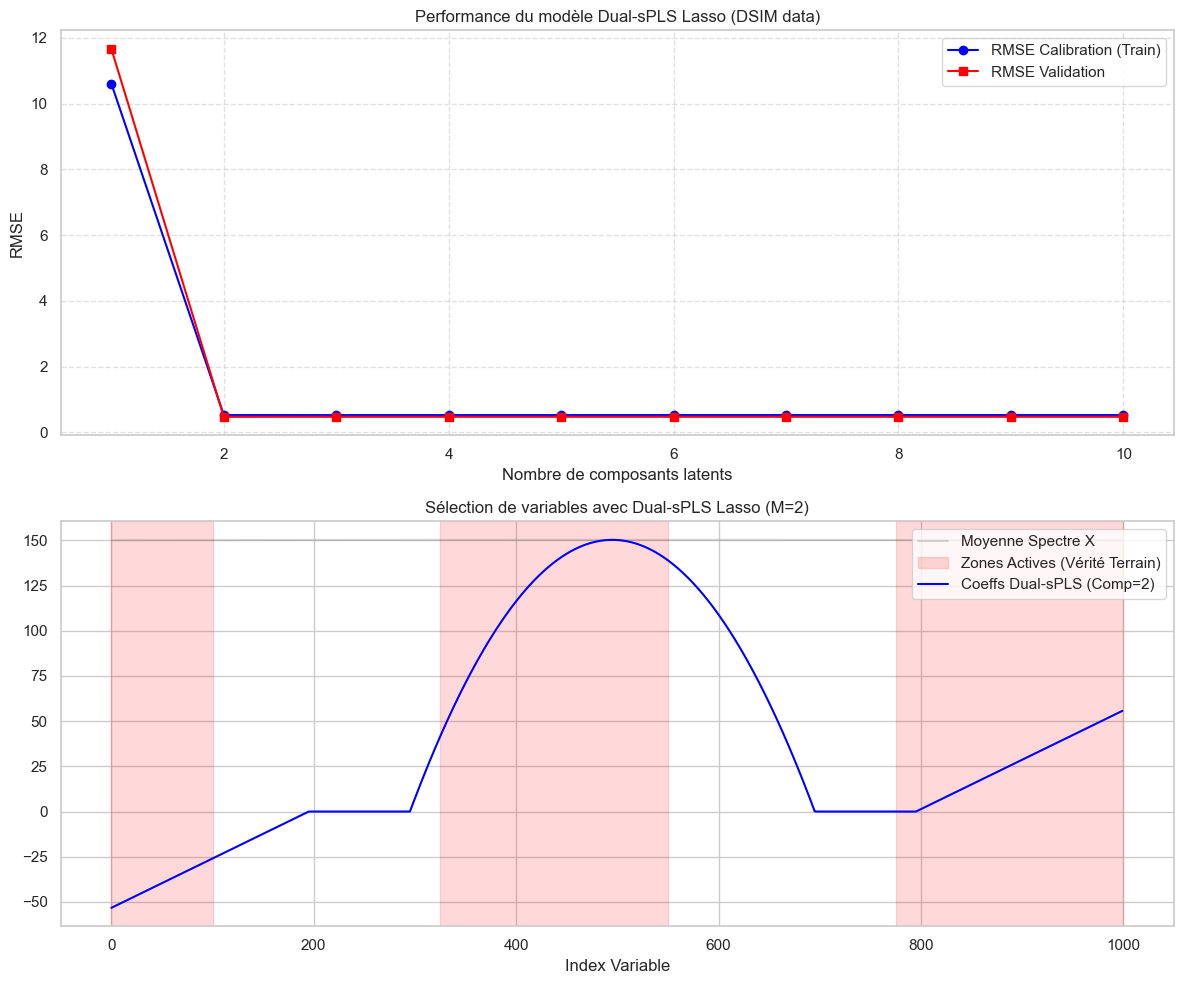

Meilleur nombre de composants : 2
Variables sélectionnées (non-zéro) : 800 / 1000


In [51]:
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from dual_spls import lasso

# 1. On suppose que X, y, et pif existent déjà (générés par ton simulateur DSIM)
# Si besoin, rappelle-toi que : n=300, p=1000
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Entraînement du modèle
# On entraine UNE SEULE FOIS avec max_components.
# Le paramètre ppnu contrôle la "Sparsity" (Lasso). Plus il est proche de 1, plus c'est clairsemé.
# Dans le papier, pour le Lasso, ils utilisent souvent des valeurs élevées pour bien nettoyer le bruit.
max_comp = 10
res = lasso.dual_spls_lasso(X_train, y_train, n_components=max_comp, ppnu=0.6)

# 3. Extraction des métriques pour chaque composant (1 à max_comp)
rmses_cal = []
rmses_val = []

for k in range(max_comp):
    # --- RMSE Calibration (Train) ---
    # Ta fonction renvoie déjà les 'fitted_values' pour chaque étape k
    y_pred_cal = res['fitted_values'][:, k]
    rmse_c = np.sqrt(mean_squared_error(y_train, y_pred_cal))
    rmses_cal.append(rmse_c)
    
    # --- RMSE Validation (Test) ---
    # Ta fonction ne fait pas de .predict() sur des nouvelles données, 
    # on doit le calculer à la main : y_hat = X_val @ beta + intercept
    beta_k = res['Bhat'][:, k]        # Coefficients pour k composants
    inter_k = res['intercept'][k]    # Intercept pour k composants
    
    y_pred_val = (X_val @ beta_k) + inter_k
    rmse_v = np.sqrt(mean_squared_error(y_val, y_pred_val))
    rmses_val.append(rmse_v)

# 4. Affichage Graphique (Reproduction Figure 4)
plt.figure(figsize=(12, 10))

# --- HAUT : Courbes RMSE ---
plt.subplot(2, 1, 1)
comps = np.arange(1, max_comp + 1)
plt.plot(comps, rmses_cal, 'o-', color='blue', label='RMSE Calibration (Train)')
plt.plot(comps, rmses_val, 's-', color='red', label='RMSE Validation')
plt.xlabel('Nombre de composants latents')
plt.ylabel('RMSE')
plt.title('Performance du modèle Dual-sPLS Lasso (DSIM data)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- BAS : Profil des Coefficients (Sélection de variables) ---
plt.subplot(2, 1, 2)

# On choisit le nombre de composants optimal (souvent 6 dans le papier pour DSIM)
# ou celui qui minimise l'erreur de validation
k_opt_idx = np.argmin(rmses_val) # Index 0-based
k_opt = k_opt_idx + 1

# Récupération des betas optimaux
beta_opt = res['Bhat'][:, k_opt_idx]

# Trace du "Spectre moyen" pour donner du contexte (en gris léger)
plt.plot(X_train.mean(axis=0), color='grey', alpha=0.3, label='Moyenne Spectre X')

# Trace des zones actives réelles (Bandes Rouges du papier)
# pif contient les indices [start1, end1, start2, end2...]
for i in range(0, len(pif), 2):
    if i+1 < len(pif):
        plt.axvspan(pif[i], pif[i+1], color='red', alpha=0.15, label='Zones Actives (Vérité Terrain)' if i==0 else "")

# Trace des coefficients trouvés par Dual-sPLS (en Bleu)
# On les met à l'échelle pour qu'ils soient visibles par rapport à X
scale_factor = np.max(np.abs(X_train.mean(axis=0))) / (np.max(np.abs(beta_opt)) + 1e-9)
plt.plot(beta_opt * scale_factor, color='blue', linewidth=1.5, label=f'Coeffs Dual-sPLS (Comp={k_opt})')

plt.title(f"Sélection de variables avec Dual-sPLS Lasso (M={k_opt})")
plt.xlabel("Index Variable")
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

print(f"Meilleur nombre de composants : {k_opt}")
print(f"Variables sélectionnées (non-zéro) : {np.sum(np.abs(beta_opt) > 1e-5)} / 1000")


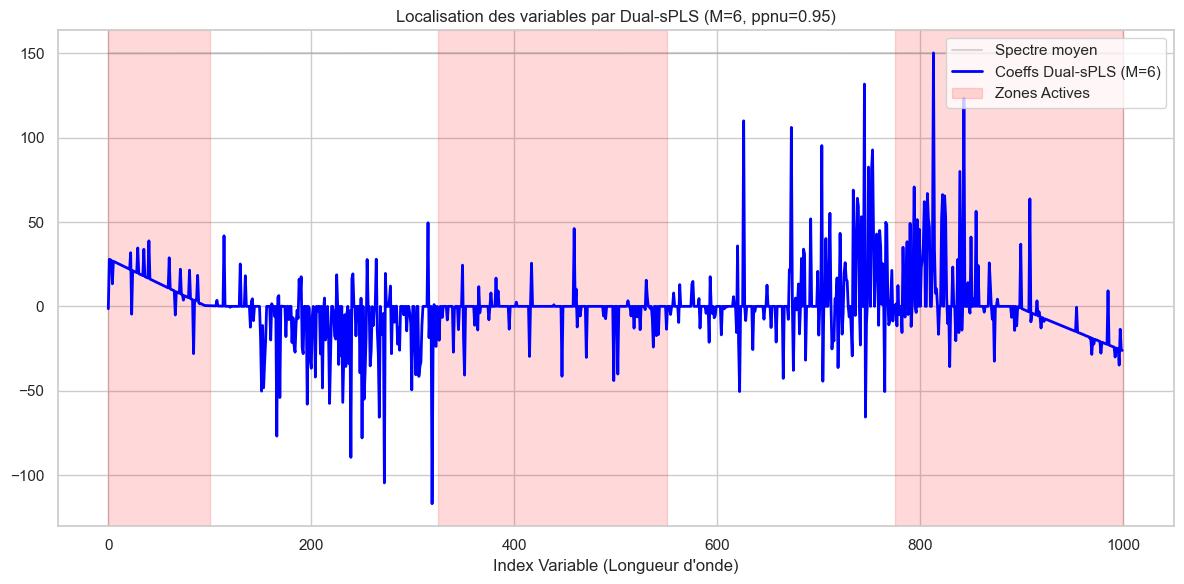

Nombre de variables éliminées (mises à zéro) : 283 sur 1000


In [52]:
# --- 1. Paramètres et Exécution du modèle ---
optimal_components = 6

# Adapte 'ppnu' (c'est ton alpha) : 0.95 impose une forte sparsité (beaucoup de zéros)
res_opt = lasso.dual_spls_lasso(X_train, y_train, n_components=optimal_components, ppnu=0.8)

# --- 2. Récupération des coefficients ---
# Ta fonction retourne 'Bhat' qui est une matrice (nbr_variables x nbr_composants)
# On veut les coefficients du modèle final (la dernière colonne, ou celle de l'index optimal_components-1)
coeffs = res_opt['Bhat'][:, -1] 

# --- 3. Visualisation (Figure 4 Bas) ---
plt.figure(figsize=(12, 6))

# A. Contexte : Spectre moyen (pour voir où sont les pics chimiques réels)
plt.plot(X_train.mean(axis=0), color='grey', alpha=0.3, label='Spectre moyen')

# B. Coefficients Dual-sPLS
# Mise à l'échelle pour l'affichage (pour que les coeffs soient visibles superposés au spectre)
# J'ajoute un petit epsilon (1e-9) pour éviter la division par zéro si coeffs est vide
coef_scale = np.max(np.abs(X_train.mean(axis=0))) / (np.max(np.abs(coeffs)) + 1e-9)

plt.plot(coeffs * coef_scale, color='blue', linewidth=2, label=f'Coeffs Dual-sPLS (M={optimal_components})')

# C. Zones Actives (Vérité Terrain)
# On suppose que 'pif' contient les bornes [début1, fin1, début2, fin2...]
# On itère par pas de 2 pour dessiner les rectangles
for i in range(0, len(pif), 2):
    if i+1 < len(pif):
        plt.axvspan(pif[i], pif[i+1], color='red', alpha=0.15, label='Zones Actives' if i==0 else "")

plt.title(f"Localisation des variables par Dual-sPLS (M={optimal_components}, ppnu=0.95)")
plt.xlabel("Index Variable (Longueur d'onde)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Petit check console pour vérifier si le Lasso a marché
n_zeros = np.sum(np.abs(coeffs) < 1e-5)
print(f"Nombre de variables éliminées (mises à zéro) : {n_zeros} sur {len(coeffs)}")

